In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("27-mall_customers.csv")

In [4]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [12]:
import math

def all_hist(data, title_pre = ""):
    num_cols = data.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_rows, 4*n_cols))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f"{title_pre} {col}")
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

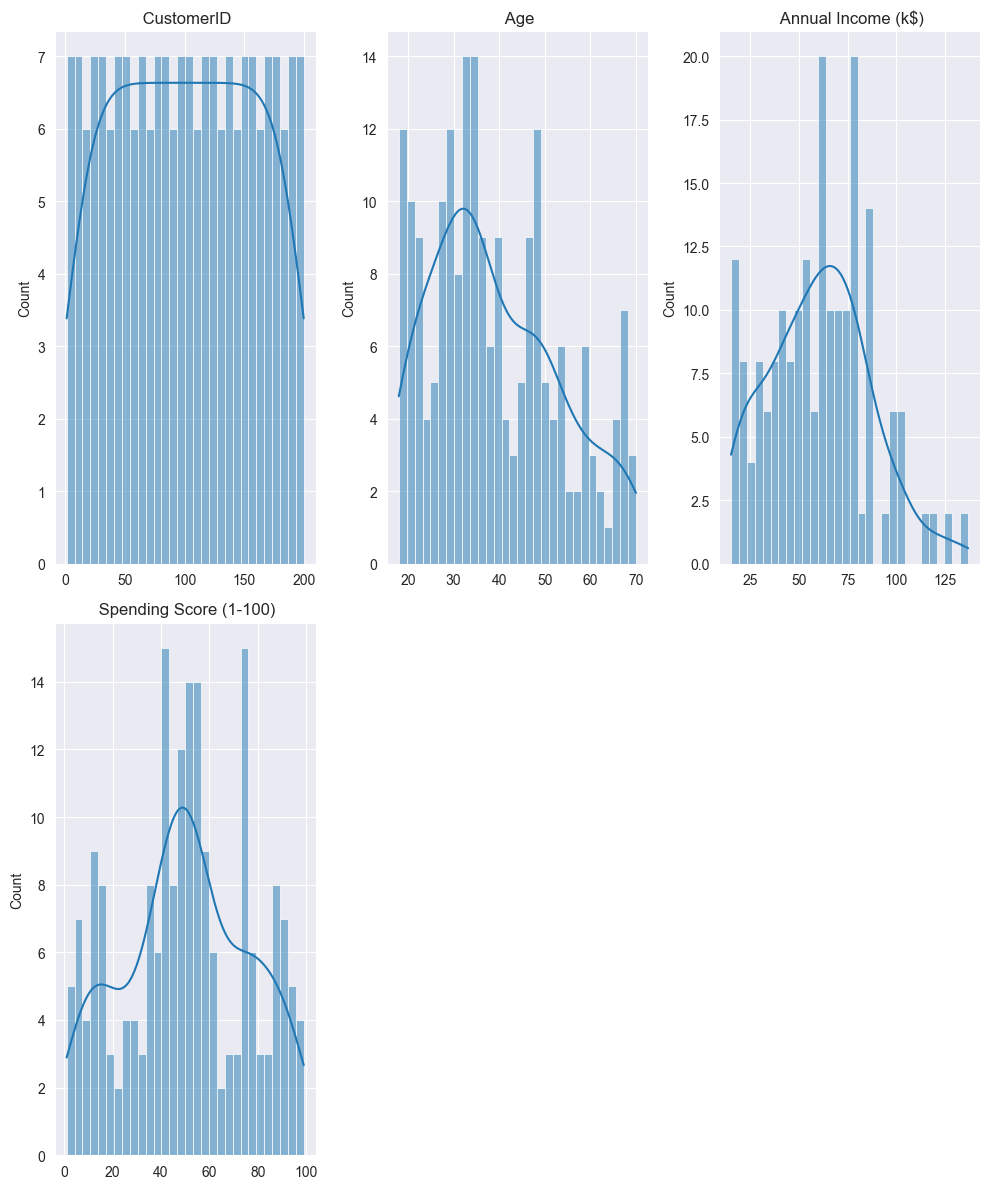

In [13]:
all_hist(data)

In [15]:
data["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoder = LabelEncoder()

data["Gender"] = label_encoder.fit_transform(data["Gender"])

In [18]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40
...,...,...,...,...,...
195,196,0,35,120,79
196,197,0,45,126,28
197,198,1,32,126,74
198,199,1,32,137,18


In [20]:
data = data.drop("CustomerID", axis=1)

In [21]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [22]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [25]:
data = pd.DataFrame(data_scaled, columns=data.columns)

In [26]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959
...,...,...,...,...
195,0.0,0.326923,0.860656,0.795918
196,0.0,0.519231,0.909836,0.275510
197,1.0,0.269231,0.909836,0.744898
198,1.0,0.269231,1.000000,0.173469


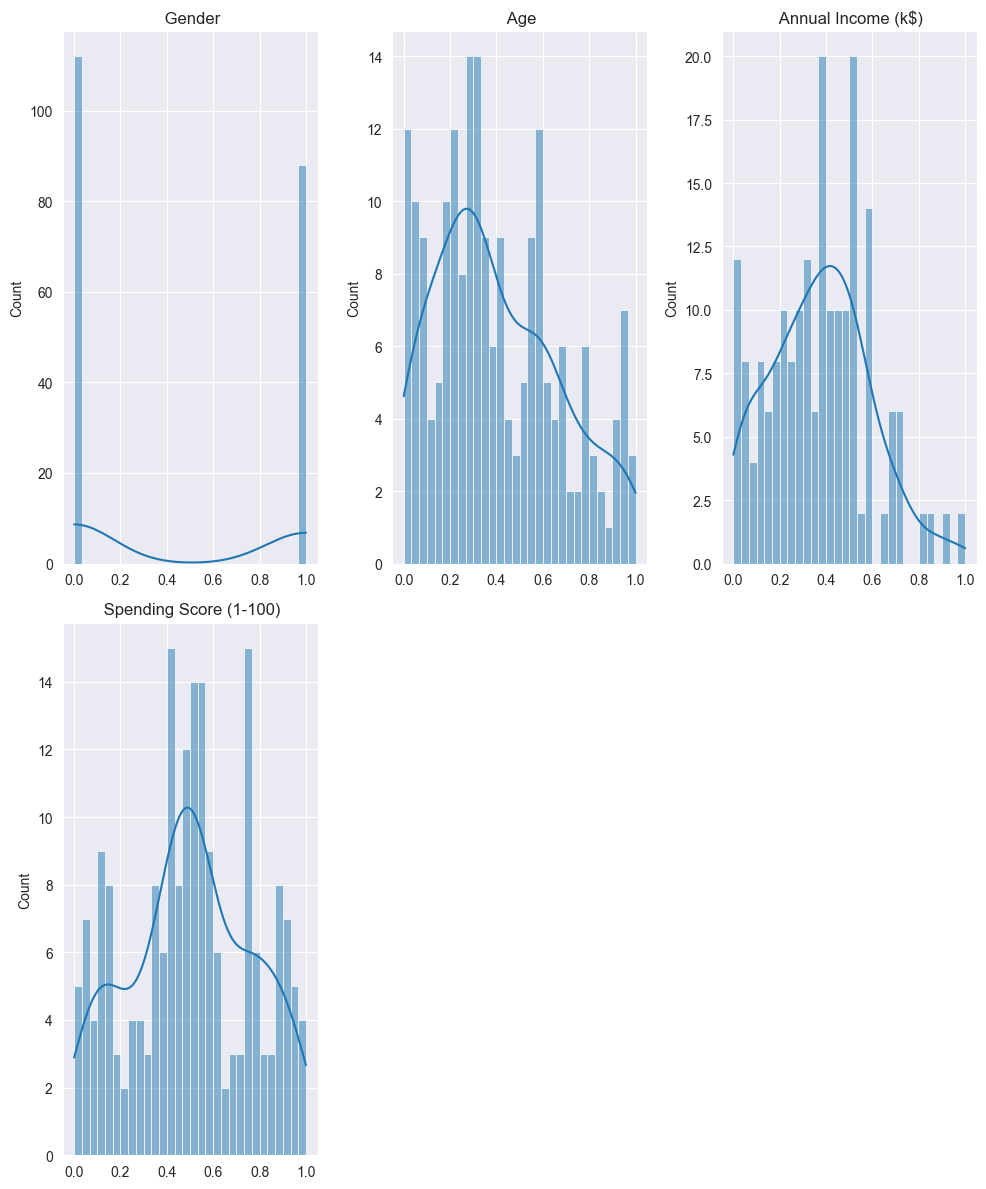

In [27]:
all_hist(data)

In [28]:
import scipy.cluster.hierarchy as sch

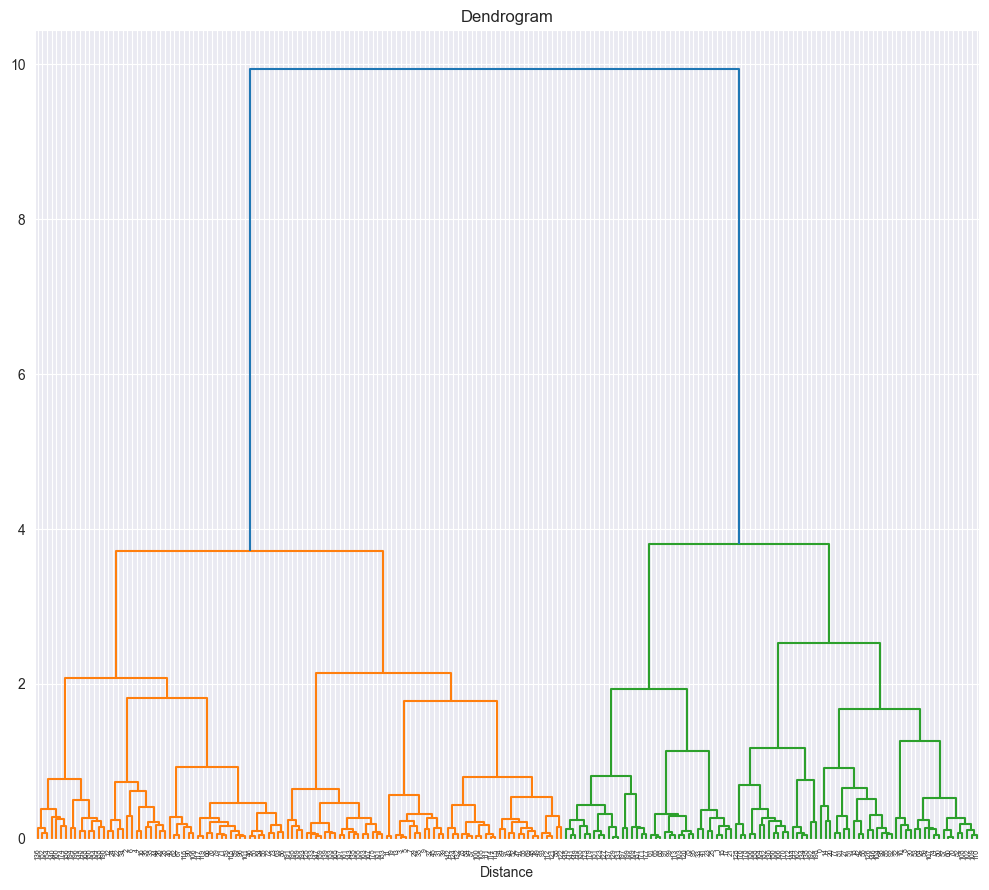

In [34]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html
# https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py

# method -> linkage{‘ward’, ‘complete’, ‘average’, ‘single’}, default=’ward’
plt.figure(figsize=(10, 9))
dendrogram = sch.dendrogram(sch.linkage(data, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Distance")
plt.tight_layout()
plt.show()

In [35]:
# we can clearly select 4 to 6 clusters from this dendrogram, lets go for 4

In [36]:
from sklearn.cluster import AgglomerativeClustering

In [37]:
hc = AgglomerativeClustering(n_clusters=4)

In [38]:
hc

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [43]:
y_hc = hc.fit_predict(data) #y_pred

In [44]:
y_hc

array([0, 2, 3, 1, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 0, 2, 3, 2, 0, 1, 0, 2,
       3, 2, 3, 2, 3, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 1, 3, 1, 3, 2, 0, 1,
       3, 1, 3, 1, 1, 1, 3, 0, 1, 0, 3, 0, 3, 0, 1, 0, 0, 2, 3, 3, 0, 2,
       3, 3, 2, 1, 0, 3, 3, 3, 0, 2, 3, 0, 1, 3, 0, 0, 0, 3, 1, 0, 3, 1,
       1, 3, 3, 2, 0, 1, 1, 2, 3, 1, 0, 2, 1, 3, 0, 2, 0, 1, 3, 0, 0, 0,
       0, 1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 0, 1, 3, 2, 0, 2, 3, 1,
       3, 1, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 2, 0, 2, 0, 2, 3, 1,
       0, 2, 0, 2, 3, 1, 0, 1, 3, 2, 3, 2, 3, 1, 3, 1, 0, 1, 3, 1, 3, 2,
       0, 2])

In [45]:
data["cluster"] = pd.DataFrame(y_hc)

In [46]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3
...,...,...,...,...,...
195,0.0,0.326923,0.860656,0.795918,1
196,0.0,0.519231,0.909836,0.275510,3
197,1.0,0.269231,0.909836,0.744898,2
198,1.0,0.269231,1.000000,0.173469,0


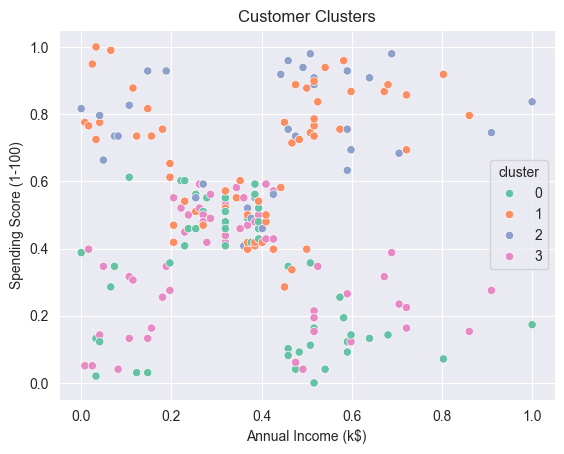

In [49]:
sns.scatterplot(data=data, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="Set2")
plt.title("Customer Clusters")
plt.show()

In [54]:
from sklearn.metrics import silhouette_score # 0-1 between, best scores nears 1
print(silhouette_score(data, y_hc))

0.7143503785893516


In [56]:
X = data[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

In [57]:
X

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959
...,...,...
195,0.860656,0.795918
196,0.909836,0.275510
197,0.909836,0.744898
198,1.000000,0.173469


In [63]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X) #y_pred
X["cluster"] = y_hc

In [64]:
X

,Annual Income (k$),Spending Score (1-100),cluster
0,0.000000,0.387755,4
1,0.000000,0.816327,3
2,0.008197,0.051020,4
3,0.008197,0.775510,3
4,0.016393,0.397959,4
...,...,...,...
195,0.860656,0.795918,0
196,0.909836,0.275510,1
197,0.909836,0.744898,0
198,1.000000,0.173469,1


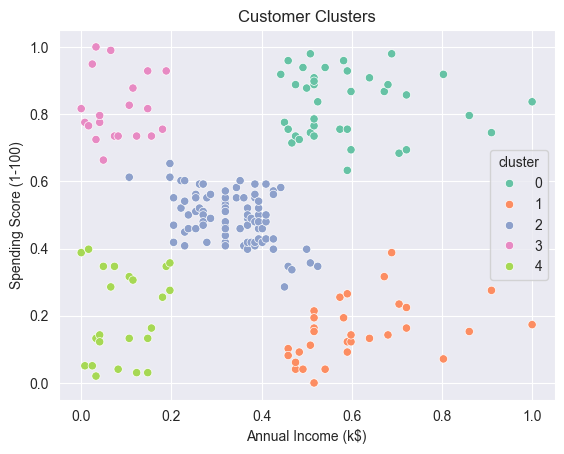

In [65]:
sns.scatterplot(data=X, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="Set2")
plt.title("Customer Clusters")
plt.show()

In [66]:
print(silhouette_score(X, y_hc))

0.8524094908064438


In [67]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [68]:
data = pd.read_csv("27-mall_customers.csv")
data = data.drop("CustomerID", axis = 1)
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])

features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_4d = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

for feats in [features_2d, features_3d, features_4d]:
    X = data[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)

    silhouette_scores = silhouette_score(X_scaled, y_hc)
    davies_bouldin_scores = davies_bouldin_score(X_scaled, y_hc)
    calinski_harabasz_scores = calinski_harabasz_score(X_scaled, y_hc)

    print(f"Features: {feats}")
    print(f"Silhouette Scores: {silhouette_scores}")
    print(f"Davies Bouldin Scores: {davies_bouldin_scores}")
    print(f"Calinski Harabasz Scores: {calinski_harabasz_scores}")
    print("\n")

Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.5582698727196419
Davies Bouldin Scores: 0.5734519252471811
Calinski Harabasz Scores: 258.97400737720704


Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.3955454334726547
Davies Bouldin Scores: 0.8746143334035464
Calinski Harabasz Scores: 123.99070840826577


Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.35032447507156306
Davies Bouldin Scores: 1.0941951795238571
Calinski Harabasz Scores: 163.46602356383625




In [69]:
from sklearn.cluster import KMeans

In [71]:
data = pd.read_csv("27-mall_customers.csv")
data = data.drop("CustomerID", axis = 1)
le = LabelEncoder()
data["Gender"] = le.fit_transform(data["Gender"])

features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
features_4d = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

for feats in [features_2d, features_3d, features_4d]:
    X = data[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_kmeans = kmeans.fit_predict(X_scaled)

    silhouette_scores = silhouette_score(X_scaled, y_kmeans)
    davies_bouldin_scores = davies_bouldin_score(X_scaled, y_kmeans)
    calinski_harabasz_scores = calinski_harabasz_score(X_scaled, y_kmeans)

    print(f"Features: {feats}")
    print(f"Silhouette Scores: {silhouette_scores}")
    print(f"Davies Bouldin Scores: {davies_bouldin_scores}")
    print(f"Calinski Harabasz Scores: {calinski_harabasz_scores}")
    print("\n")

Features: ['Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.558627081394975
Davies Bouldin Scores: 0.5668527515455375
Calinski Harabasz Scores: 264.5866380358972


Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.40877100822186796
Davies Bouldin Scores: 0.882850308990102
Calinski Harabasz Scores: 127.87479402345603


Features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Silhouette Scores: 0.37073434917008075
Davies Bouldin Scores: 1.0023045721982862
Calinski Harabasz Scores: 172.98733319860088


